In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('darkgrid')

from sklearn.base import BaseEstimator, clone

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, TargetEncoder, PolynomialFeatures
from sklearn.feature_selection import chi2, VarianceThreshold, SelectKBest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTENC
from imblearn.under_sampling import EditedNearestNeighbours, CondensedNearestNeighbour, NearMiss
from imblearn.pipeline import Pipeline
import umap.umap_ as umap

# !pip install optuna

import optuna
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_param_importances

import time

seed=42

In [2]:
df = pd.read_csv('covtype_decoded.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Elevation                           581012 non-null  int64 
 1   Aspect                              581012 non-null  int64 
 2   Slope                               581012 non-null  int64 
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64 
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64 
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64 
 6   Hillshade_9am                       581012 non-null  int64 
 7   Hillshade_Noon                      581012 non-null  int64 
 8   Hillshade_3pm                       581012 non-null  int64 
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64 
 10  Wilderness                          581012 non-null  object
 11  Soil_Type                           581

In [4]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [5]:
y.value_counts()

Cover_Type
Lodgepole Pine       283301
Spruce/Fir           211840
Ponderosa Pine        35754
Krummholz             20510
Douglas-fir           17367
Aspen                  9493
Cottonwood/Willow      2747
Name: count, dtype: int64

In [6]:
num = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points']
cat = [ 'Wilderness', 'Soil_Type']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.02,random_state=seed,stratify=y)

In [8]:
print('X_train shape ', X_train.shape)
print('X_test shape ', X_test.shape)

X_train shape  (569391, 12)
X_test shape  (11621, 12)


In [9]:
le = LabelEncoder()
y_train_nc = le.fit_transform(y_train)
y_test_nc = le.fit_transform(y_test)

In [10]:
te = ColumnTransformer([
    ('te', TargetEncoder().set_output(transform='pandas'), cat)
],verbose_feature_names_out=False,remainder='passthrough').set_output(transform='pandas')

preprocessing = Pipeline([
    ('te', te),
    ('ss', StandardScaler().set_output(transform='pandas')),
    ('poly',PolynomialFeatures(degree=2,include_bias=False).set_output(transform='pandas'))
])

X_train_poly = preprocessing.fit_transform(X_train,y_train)

In [11]:
def model_trainer(model,model_params,X,y,sample_weights=None,n_trials=30):
    def objective(trial):
        params = model_params(trial)
        model.set_params(**params)
        stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        score = cross_val_score(model, X, y, params={'sample_weight':sample_weights}, cv=stratified_cv, scoring='f1_weighted').mean()
        return score

    study = optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective,n_trials=n_trials)

    model.set_params(**study.best_trial.params)
    model.fit(X,y,sample_weight=sample_weights)

    return study, model

In [12]:
# def xgb_params(trial):
#     return {
#                 'max_depth': trial.suggest_int('max_depth', 3, 12),
#                 'max_leaves': trial.suggest_int('max_leaves', 8, 256),
#                 'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
#                 'gamma': trial.suggest_float('gamma', 0.0, 1.0),
#                 'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#                 'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
#                 'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.6, 1.0),
#                 'colsample_bynode': trial.suggest_float('colsample_bynode', 0.6, 1.0),
#                 'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
#                 'n_estimators': trial.suggest_int('n_estimators', 50, 1000),
#                 'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
#                 'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
#                 'max_delta_step': trial.suggest_int('max_delta_step', 0, 10),
#                 'max_bin':trial.suggest_int('max_bin', 64, 1024, step=64),
#             }

# xgb = XGBClassifier(tree_method='hist',
#                     eval_metric='mlogloss',
#                     # device='cuda',
#                     random_state=seed)

# sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_nc)

# xgb_study, xgb_model = model_trainer(xgb,xgb_params,X_train_poly,y_train_nc,sample_weights)

```
{
'max_depth': 9,
'max_leaves': 256,
'min_child_weight': 3,
'gamma': 0.22081432745617946,
'subsample': 0.6817427853448248,
'colsample_bytree': 0.6608758789185505,
'colsample_bylevel': 0.7714211978064195,
'colsample_bynode': 0.7846413540252581,
'learning_rate': 0.1939130448097222,
'n_estimators': 475,
'reg_alpha': 0.6129627364538431,
'reg_lambda': 0.2427378315913879,
'max_delta_step': 0,
'max_bin': 896
}
```

In [13]:
best_params = {
'max_depth': 9,
'max_leaves': 256,
'min_child_weight': 3,
'gamma': 0.22081432745617946,
'subsample': 0.6817427853448248,
'colsample_bytree': 0.6608758789185505,
'colsample_bylevel': 0.7714211978064195,
'colsample_bynode': 0.7846413540252581,
'learning_rate': 0.1939130448097222,
'n_estimators': 475,
'reg_alpha': 0.6129627364538431,
'reg_lambda': 0.2427378315913879,
'max_delta_step': 0, 
# 'max_bin': 896
}

In [14]:
xgb = XGBClassifier(tree_method='hist',
                    eval_metric='mlogloss',
                    # device='cuda',
                    random_state=seed)
xgb.set_params(**best_params)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.7714211978064195,
              colsample_bynode=0.7846413540252581,
              colsample_bytree=0.6608758789185505, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='mlogloss', feature_types=None, feature_weights=None,
              gamma=0.22081432745617946, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1939130448097222,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=0, max_depth=9, max_leaves=256, min_child_weight=3,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=475, n_jobs=None, num_parallel_tree=None, ...)

In [15]:
xgb.fit(X_train_poly,y_train_nc)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.7714211978064195,
              colsample_bynode=0.7846413540252581,
              colsample_bytree=0.6608758789185505, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='mlogloss', feature_types=None, feature_weights=None,
              gamma=0.22081432745617946, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1939130448097222,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=0, max_depth=9, max_leaves=256, min_child_weight=3,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=475, n_jobs=None, num_parallel_tree=None, ...)

In [18]:
y_train_pred = le.inverse_transform(xgb.predict(X_train_poly))
print(classification_report(y_train_pred,y_train))

                   precision    recall  f1-score   support

            Aspen       1.00      1.00      1.00      9302
Cottonwood/Willow       1.00      1.00      1.00      2692
      Douglas-fir       1.00      1.00      1.00     17018
        Krummholz       1.00      1.00      1.00     20100
   Lodgepole Pine       1.00      1.00      1.00    277727
   Ponderosa Pine       1.00      1.00      1.00     35040
       Spruce/Fir       1.00      1.00      1.00    207512

         accuracy                           1.00    569391
        macro avg       1.00      1.00      1.00    569391
     weighted avg       1.00      1.00      1.00    569391



In [19]:
X_test_poly = preprocessing.transform(X_test)
y_test_pred = le.inverse_transform(xgb.predict(X_test_poly))
print(classification_report(y_test_pred,y_test))

                   precision    recall  f1-score   support

            Aspen       0.92      0.93      0.92       187
Cottonwood/Willow       0.87      0.92      0.90        52
      Douglas-fir       0.98      0.96      0.97       355
        Krummholz       0.97      0.99      0.98       404
   Lodgepole Pine       0.98      0.97      0.98      5684
   Ponderosa Pine       0.97      0.98      0.97       708
       Spruce/Fir       0.97      0.97      0.97      4231

         accuracy                           0.97     11621
        macro avg       0.95      0.96      0.96     11621
     weighted avg       0.97      0.97      0.97     11621



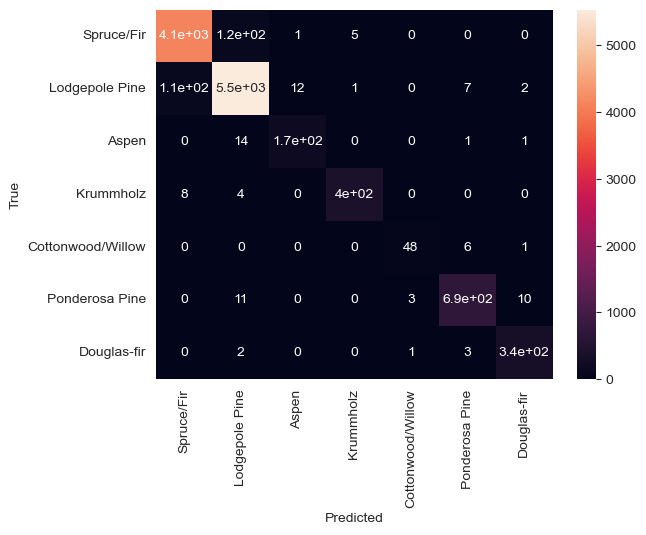

In [24]:
cm = confusion_matrix(y_test,y_test_pred,labels=y_test.unique())
cm_hm = sns.heatmap(cm,annot=True)
cm_hm.set_xticklabels(y_test.unique(),rotation=90)
cm_hm.set_yticklabels(y_test.unique(),rotation=0)
cm_hm.set_xlabel('Predicted')
cm_hm.set_ylabel('True')
plt.show()

In [21]:
mistake_filter = y_test != y_test_pred

In [22]:
um = umap.UMAP()
reduced = um.fit_transform(X_test_poly)

C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:301: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


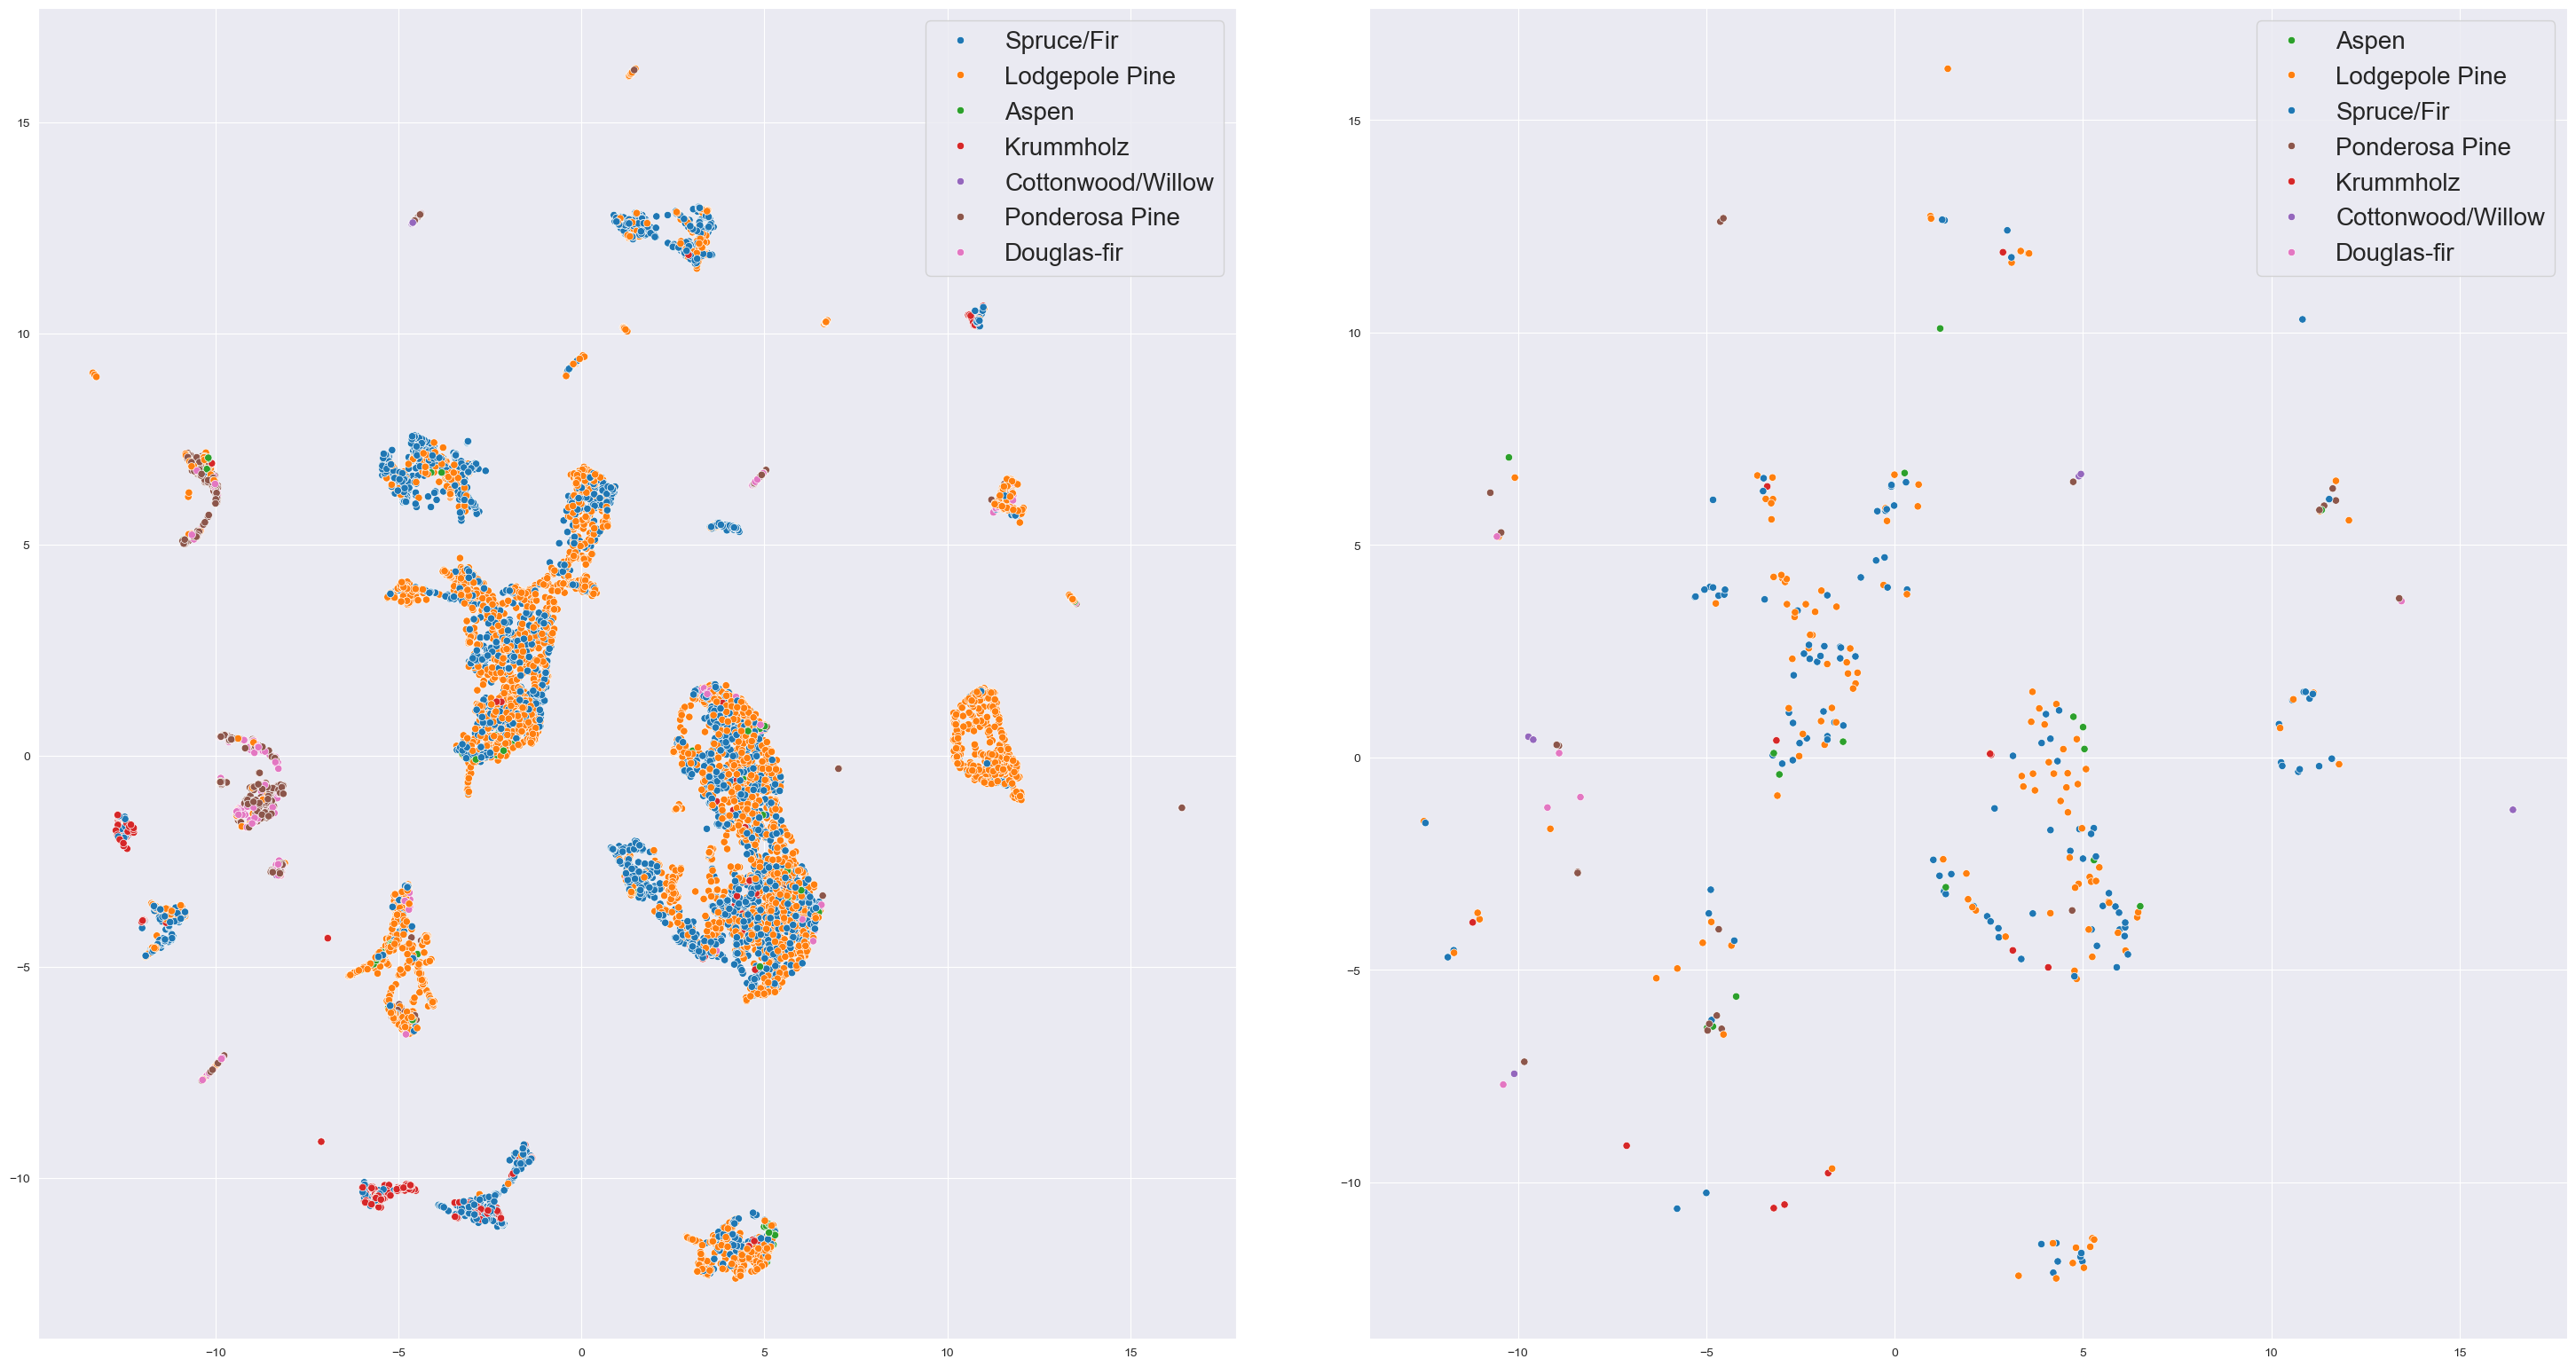

In [23]:
unique_categories = y_test[~mistake_filter].unique()
palette = sns.color_palette()
palette = dict(zip(unique_categories, palette))

fig = plt.figure(figsize=(15,15))
right = fig.add_axes([0,0,.9,1])
sns.scatterplot(x=reduced[~mistake_filter,0],y=reduced[~mistake_filter,1],hue=y_test[~mistake_filter],axes=right,palette=palette)
plt.legend(fontsize=20)
colors = sns.color_palette()[:y_test[~mistake_filter].nunique()]


wrong = fig.add_axes([1,0,.9,1])
sns.scatterplot(x=reduced[mistake_filter,0],y=reduced[mistake_filter,1],hue=y_test[mistake_filter],axes=wrong,palette=palette)
plt.legend(fontsize=20)
plt.show()